# Reachability of the Double-Zernike space by the OFC v-modes

**Study:** `smatrix_vmode` · **Companion to:** `code/smatrix_vmode/plot_vmode_dof_matrix.py`

This notebook is the **derivation** behind page 4 of
`output/smatrix_vmode/vmode_dof_matrix_<scheme>.pdf`. The script produces the numbers and
the figures for the pipeline; this notebook records *why* those are the right quantities
to plot, with the algebra written out.

The sensitivity matrix $S$ maps degrees of freedom (DOF) to a Double-Zernike (DZ)
wavefront. Its singular value decomposition $S = U\,\Sigma\,V^\top$ gives **v-modes**
(columns of $V$, in DOF space) and **u-modes** (columns of $U$, in DZ space), with
$S\,v_i = \sigma_i\,u_i$.

## Why $(k,j)$ isolation is a misleading view

An obvious-looking question is: *if I want a unit aberration at exactly $(k,j)$ and
nothing else, which DOFs produce that?* But the $(k,j)$ axes are a **coordinate choice** —
nothing about the optics distinguishes one DZ basis vector from another linear combination
of them. The reachable subspace $\mathrm{col}(S)$ has an *intrinsic* orthonormal basis:
the columns of $U$. Those are the directions the actuators actually produce.

So the better question is: **how much of each u-mode lives inside the elementary DZ
$\mathbf{e}_{k,j}$?** That is exactly the row of $U$ for index $(k,j)$, and the squared
row-sum is the reachability fraction $f_{k,j}$ plotted on page 4 of the PDF.

## Contents

1. Setup — the restricted, normalized $S$ and its SVD
2. DZ x u-mode dependence — the rows of $U$
3. Reachability $f_{k,j}$ and the per-DZ residual
4. Residual after a u-mode fit — an elementary DZ
5. Residual after a u-mode fit — a random DZ vector

Row order in DZ space is fixed by `k_range` (outer) x `j_range` (inner), with helpers
`dz_row(k, j)`, `dz_kj(row)`, `dz_labels` and `dz_ylabels`.

> The V-matrix and u-mode heatmaps that used to be sections 1-2 here are now pages 1 and 3
> of the script's PDF, and are not duplicated in this notebook.


In [1]:
import sys
from pathlib import Path

# Walk up to the topic directory (the one containing code/), which works at any depth.
_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))      # flat cross-study modules

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from lsst.ts.ofc import OFCData

%matplotlib inline


In [2]:
import os
import yaml

# Normalization weights: same file the production OFC uses, resolved from the
# environment. ofc_svd.DEFAULT_NORM_YAML is 'range0.5_fwhm-0.15.yaml'; the weights are
# w_i = r_i**0.5 * f_i**-0.15 in the DOF units of each degree of freedom.
NORM_YAML = 'range0.5_fwhm-0.15.yaml'
_mttcs = os.environ.get(
    'TS_CONFIG_MTTCS_DIR',
    '/sdf/group/rubin/u/roodman/LSST/packages/ts_config_mttcs')
norm_path = Path(_mttcs) / 'MTAOS' / 'v13' / 'ofc' / 'normalization_weights' / NORM_YAML
if not norm_path.exists():                      # v13 absent -> unversioned layout
    norm_path = Path(_mttcs) / 'MTAOS' / 'ofc' / 'normalization_weights' / NORM_YAML
print('normalization weights:', norm_path)

normalization_weights = np.array(yaml.safe_load(norm_path.read_text()))
normalization_matrix = np.diag(normalization_weights)

ofc_data = OFCData('lsst')
S_full = ofc_data.sensitivity_matrix              # (n_field=31, n_zk=29, n_dof=50)
n_field, n_zk, n_dof = S_full.shape

# Restrict (k, j) to the analysis range. Both bounds are inclusive on the low end;
# k_max / j_max are EXCLUSIVE (slice-style) so changing them is unambiguous.
k_min, k_max = 1, 6                               # fields k = 1..5
j_min, j_max = 4, n_zk                            # Zernikes j = 4..28

k_range = np.arange(k_min, k_max + 1)                 # values of k kept, in row order
j_range = np.arange(j_min, j_max)                 # values of j kept, in row order
n_k, n_j = len(k_range), len(j_range)

# Sensitivity matrix restricted to (k_range, j_range), with right-side normalization.
S = (S_full[k_min:k_max+1, j_min:j_max, :].reshape(-1, n_dof)) @ normalization_matrix
n_wf = S.shape[0]
assert n_wf == n_k * n_j

# Row layout: row = (k - k_min) * n_j + (j - j_min). k is the OUTER index.
def dz_row(k, j):
    """Row index in S / U for the elementary DZ at field k, Zernike j."""
    if k not in k_range or j not in j_range:
        raise ValueError(f"(k={k}, j={j}) is outside k_range={list(k_range)} or j_range={list(j_range)}")
    return int((k - k_min) * n_j + (j - j_min))

def dz_kj(row):
    """(k, j) for a row index in S / U."""
    ki, ji = divmod(int(row), n_j)
    return int(k_range[ki]), int(j_range[ji])

dz_labels  = [(int(k), int(j)) for k in k_range for j in j_range]
dz_ylabels = [f'({k},{j})' for k, j in dz_labels]

print('S shape:', S.shape, ' n_wf =', n_wf, ' (n_k =', n_k, ', n_j =', n_j, ')')
print('row(k=1, j=4) =', dz_row(1, 4), '   kj(row=0)  =', dz_kj(0))
print('row(k=5, j=28)=', dz_row(5, 28), '  kj(row=-1) =', dz_kj(n_wf-1))


normalization weights: /sdf/home/r/roodman/u/LSST/packages/ts_config_mttcs/MTAOS/v13/ofc/normalization_weights/range0.5_fwhm-0.15.yaml


S shape: (150, 50)  n_wf = 150  (n_k = 6 , n_j = 25 )
row(k=1, j=4) = 0    kj(row=0)  = (1, 4)
row(k=5, j=28)= 124   kj(row=-1) = (6, 28)


In [3]:
U, Sigma, Vh = np.linalg.svd(S, full_matrices=False)
V = Vh.T
rank_eps = 1e-10 * Sigma[0]
rank = int((Sigma > rank_eps).sum())
# n_keep here is an illustrative truncation for the algebra below, NOT a production
# scheme: the pipeline uses 12 retained v-modes for 22 DOF and 34 for 50 DOF (see
# SCHEMES in code/smatrix_vmode/plot_vmode_dof_matrix.py). The reachability fractions
# printed below therefore differ from page 4 of the PDF, which uses the real schemes.
n_keep = 25
U_eff = U[:, :n_keep]
print('U:', U.shape, ' Sigma:', Sigma.shape, ' V:', V.shape, ' rank:', rank)
print('U_eff:', U_eff.shape)


U: (150, 50)  Sigma: (50,)  V: (50, 50)  rank: 50
U_eff: (150, 25)


In [4]:
def set_dz_yaxis(ax, fontsize=7, every=1):
    """Label the y-axis with (k,j) for the current DZ row layout."""
    ticks = np.arange(0, n_wf, every)
    ax.set_yticks(ticks)
    ax.set_yticklabels([dz_ylabels[i] for i in ticks], fontsize=fontsize)
    ax.set_ylabel('(k, j)')
    # Faint horizontal lines between k blocks for readability.
    for ki in range(1, n_k):
        ax.axhline(ki * n_j - 0.5, color='k', lw=0.4, alpha=0.25)


## 2. DZ x u-mode dependence

The columns of $U$ are an *orthonormal* basis of $\mathrm{col}(S)$. So for any DZ index $(k,j)$ the natural decomposition is

$$ \mathbf{e}_{k,j} \;=\; \underbrace{\sum_{i=1}^{50} U_{(k,j),\,i}\;\mathbf{u}_i}_{\text{reachable part}} \;+\; \text{(residual orthogonal to }\mathrm{col}(S)\text{)}. $$

The **row of $U$ for $(k,j)$** answers "how much does this DZ depend on each U-mode?". Squaring gives an energy decomposition; the row-sum is exactly $f_{k,j}$, the reachability fraction.

Below: heatmap of $U^2$. Columns are U-modes (orthonormal — no double-counting, no cancellation artefacts) instead of DOFs.


max |P_diag - row-sum(U^2)| = 2.22e-16


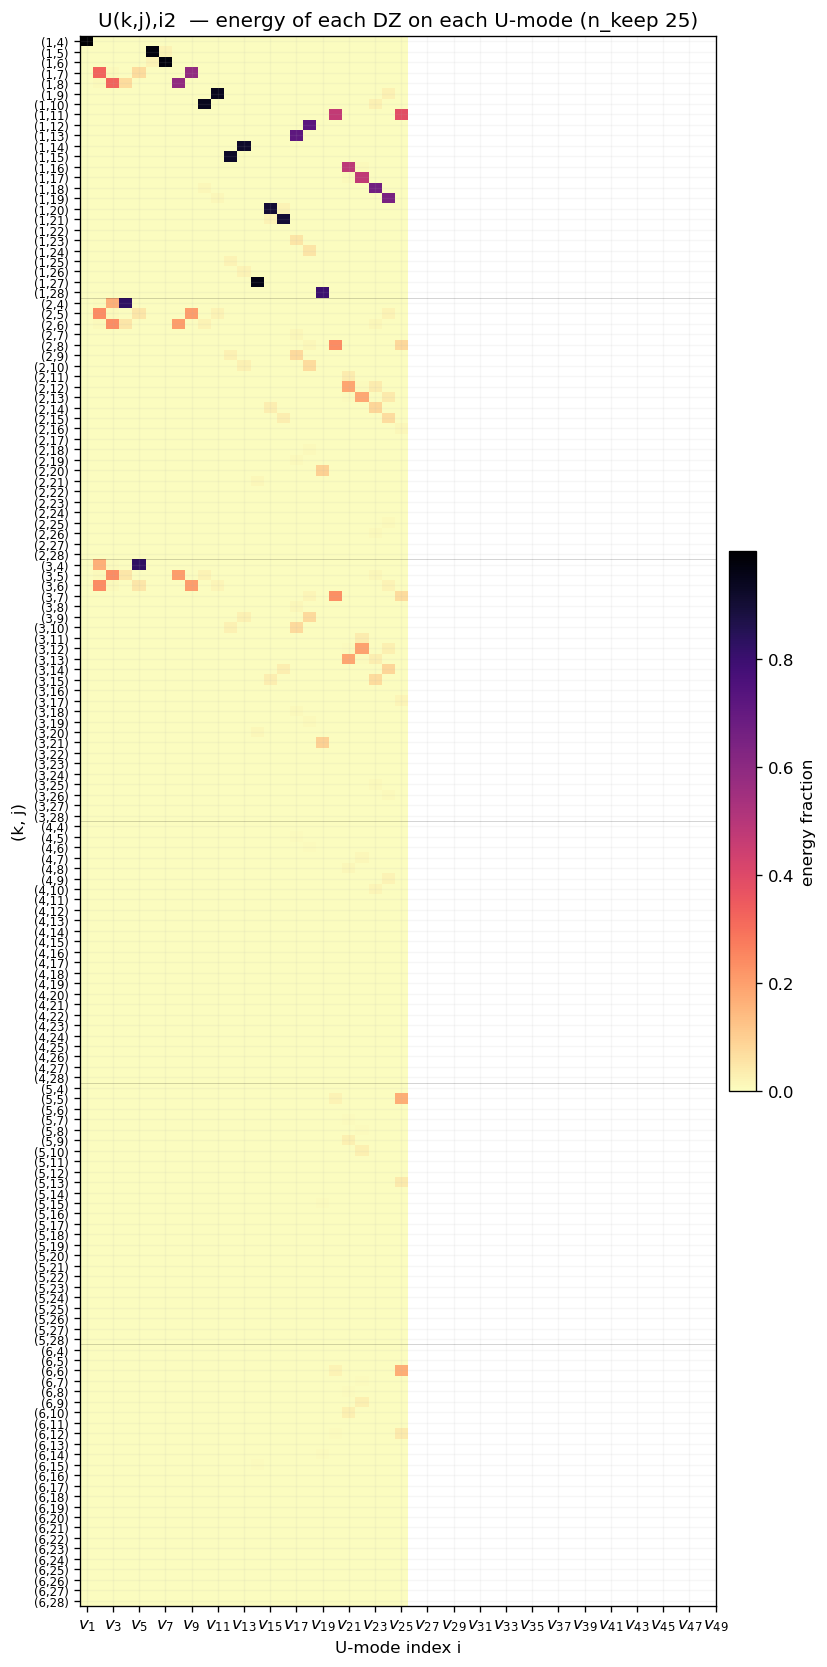

In [5]:
U2 = U_eff ** 2

fig, ax = plt.subplots(figsize=(7, 14), dpi=120)
im = ax.imshow(U2, aspect='auto', cmap='magma_r',
               vmin=0.0, vmax=U2.max(), interpolation='nearest')
ax.set_xlabel('U-mode index i')
ax.set_xticks(np.arange(rank)[::2], [f'$v_{{{i + 1}}}$' for i in range(rank)][::2])
ax.set_title(rf'U(k,j),i2  — energy of each DZ on each U-mode (n_keep {n_keep})')
set_dz_yaxis(ax, fontsize=7)
ax.grid(alpha=0.1)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='energy fraction')
fig.tight_layout()

# Sanity: the explicit projector diag equals row-sums of U^2.
P_diag = (U_eff @ U_eff.T).diagonal()
print(f'max |P_diag - row-sum(U^2)| = {np.max(np.abs(P_diag - U2.sum(axis=1))):.2e}')


## 3. Reachability $f_{k,j}$ and per-DZ residual

Aggregating section 4: the row-sum of $U^2$ is the fraction of $\mathbf{e}_{k,j}$ inside $\mathrm{col}(S)$,

$$ f_{k,j} \;=\; \|U^\top \mathbf{e}_{k,j}\|^2 \;\in\;[0,1], $$

and the per-DZ residual energy is $1 - f_{k,j}$, i.e. the squared norm of $(I-UU^\top)\mathbf{e}_{k,j}$. Plotted the same way as the reachability heatmap in `jk_coverage.ipynb`: rows = field $k$, columns = Zernike $j$, values in %.

(Caveat: these numbers are computed inside the *restricted* DZ space $k\in$`k_range`, $j\in$`j_range` and after right-side normalization. The reachable subspace is still $\mathrm{col}(S)$ — only the geometry of the elementary $\mathbf{e}_{k,j}$ inside that restricted space is what we're measuring.)


mean f_(k,j)    = 16.67%
mean residual   = 83.33%
cells reachable >= 95%:  10 / 150
cells residual  >= 95%:  104 / 150


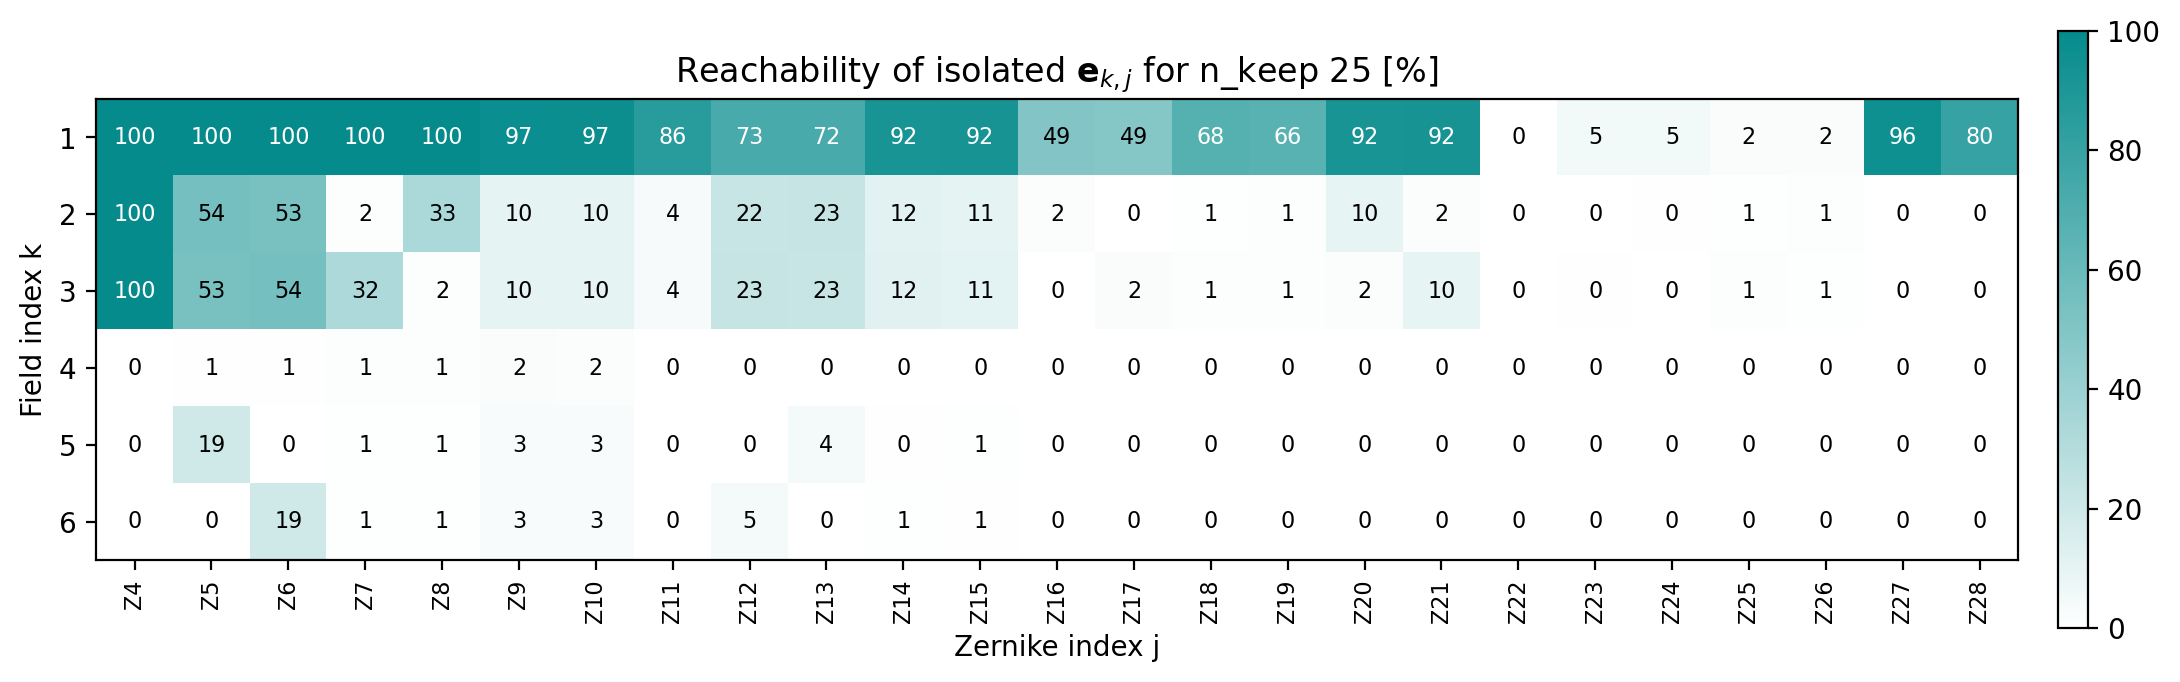

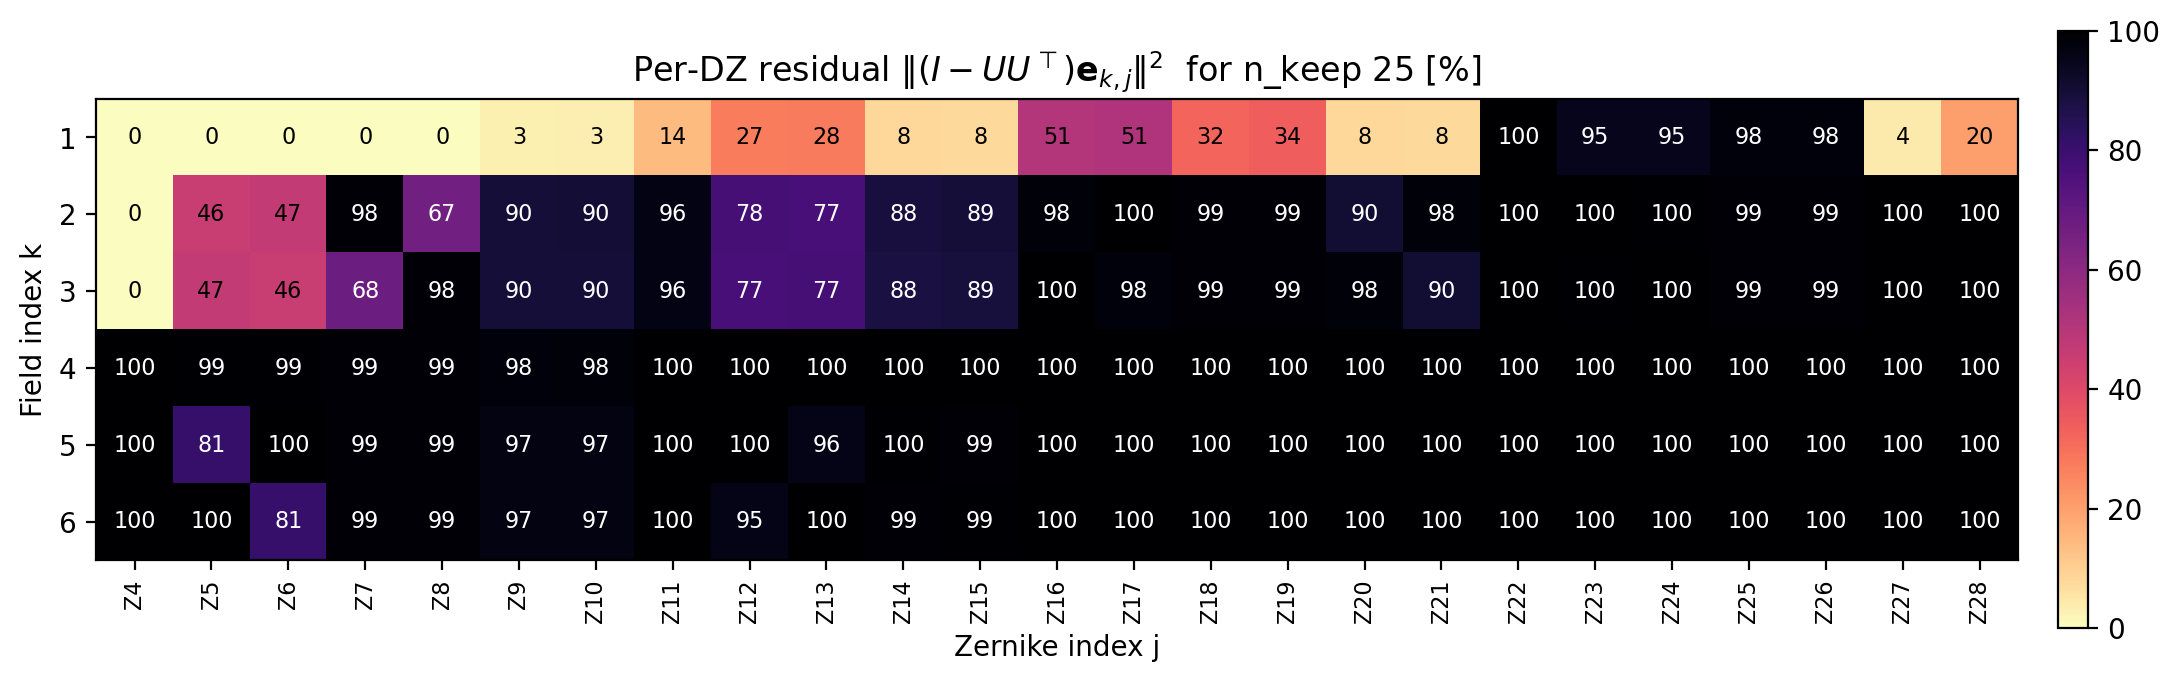

In [6]:
# Per-(k, j) reachability fraction and residual.
frac = (U_eff ** 2).sum(axis=1)                    # (n_wf,)
frac_2d = frac.reshape(n_k, n_j)                   # (n_k, n_j)
resid_2d = 1.0 - frac_2d

rubin_cmap = LinearSegmentedColormap.from_list('rubin', ['#ffffff', '#058B8C'])

def heatmap_kj(values_2d, title, cmap, vmin, vmax, fmt='{:.0f}', text_thresh=60):
    fig, ax = plt.subplots(figsize=(11, 0.55 * n_k + 1.2), dpi=200)
    im = ax.imshow(values_2d, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(n_j))
    ax.set_xticklabels([f'Z{j}' for j in j_range], rotation=90, fontsize=8)
    ax.set_yticks(np.arange(n_k))
    ax.set_yticklabels([f'{k}' for k in k_range], fontsize=10)
    ax.set_xlabel('Zernike index j')
    ax.set_ylabel('Field index k')
    ax.set_aspect('equal')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.015, pad=0.02)
    for ki in range(n_k):
        for ji in range(n_j):
            v = values_2d[ki, ji]
            ax.text(ji, ki, fmt.format(v), ha='center', va='center',
                    color='black' if v < text_thresh else 'white', fontsize=8)
    fig.tight_layout()

heatmap_kj(100 * frac_2d,
           rf'Reachability of isolated $\mathbf{{e}}_{{k,j}}$ for n_keep {n_keep} [%]',
           rubin_cmap, vmin=0, vmax=100)

heatmap_kj(100 * resid_2d,
           rf'Per-DZ residual $\|(I-UU^\top)\mathbf{{e}}_{{k,j}}\|^2$  for n_keep {n_keep} [%]',
           'magma_r', vmin=0, vmax=100, text_thresh=60)

print(f'mean f_(k,j)    = {100*frac_2d.mean():.2f}%')
print(f'mean residual   = {100*resid_2d.mean():.2f}%')
print(f'cells reachable >= 95%:  {(frac_2d >= 0.95).sum()} / {n_wf}')
print(f'cells residual  >= 95%:  {(resid_2d >= 0.95).sum()} / {n_wf}')


## 4. Residual after a u-mode fit — elementary DZ

Pick any $(k, j)$, build $\mathbf{e}_{k,j}$, and fit it in $\mathrm{col}(S)$:

$$ \mathbf{w} \;=\; \underbrace{U\,U^\top\,\mathbf{w}}_{\text{fit}} \;+\; (I - U\,U^\top)\,\mathbf{w}. $$

The reachable energy equals $f_{k,j}$ from section 5.


In [7]:
k_star, j_star = 1, 4
row = dz_row(k_star, j_star)
w = np.zeros(n_wf); w[row] = 1.0

coeffs   = U_eff.T @ w           # U-mode amplitudes
fit      = U_eff @ coeffs        # reachable part
residual = w - fit               # irreducible

print(f'(k*={k_star}, j*={j_star})   row={row}')
print(f'  ||fit||^2      = {np.dot(fit, fit):.4f}')
print(f'  ||residual||^2 = {np.dot(residual, residual):.4f}')
print(f'  f_(k,j)        = {frac[row]:.4f}      (should equal ||fit||^2)')


(k*=1, j*=4)   row=0
  ||fit||^2      = 1.0000
  ||residual||^2 = 0.0000
  f_(k,j)        = 1.0000      (should equal ||fit||^2)


## 5. Residual after a u-mode fit — random DZ vector

Same three lines, but $\mathbf{w}$ is now a random Gaussian vector in DZ space (i.i.d. components, then unit-normalized). The reachable fraction is no longer a single $f_{k,j}$ — it's the projector's average action on $\mathbf{w}$, which over many draws converges to $\mathrm{rank}(S)/n_{\mathrm{wf}}$.


random DZ (||w||^2 = 1.0000):
  ||fit||^2      = 0.1473
  ||residual||^2 = 0.8527
  rank/n_wf      = 50/150 = 0.3333   (expectation over random w)


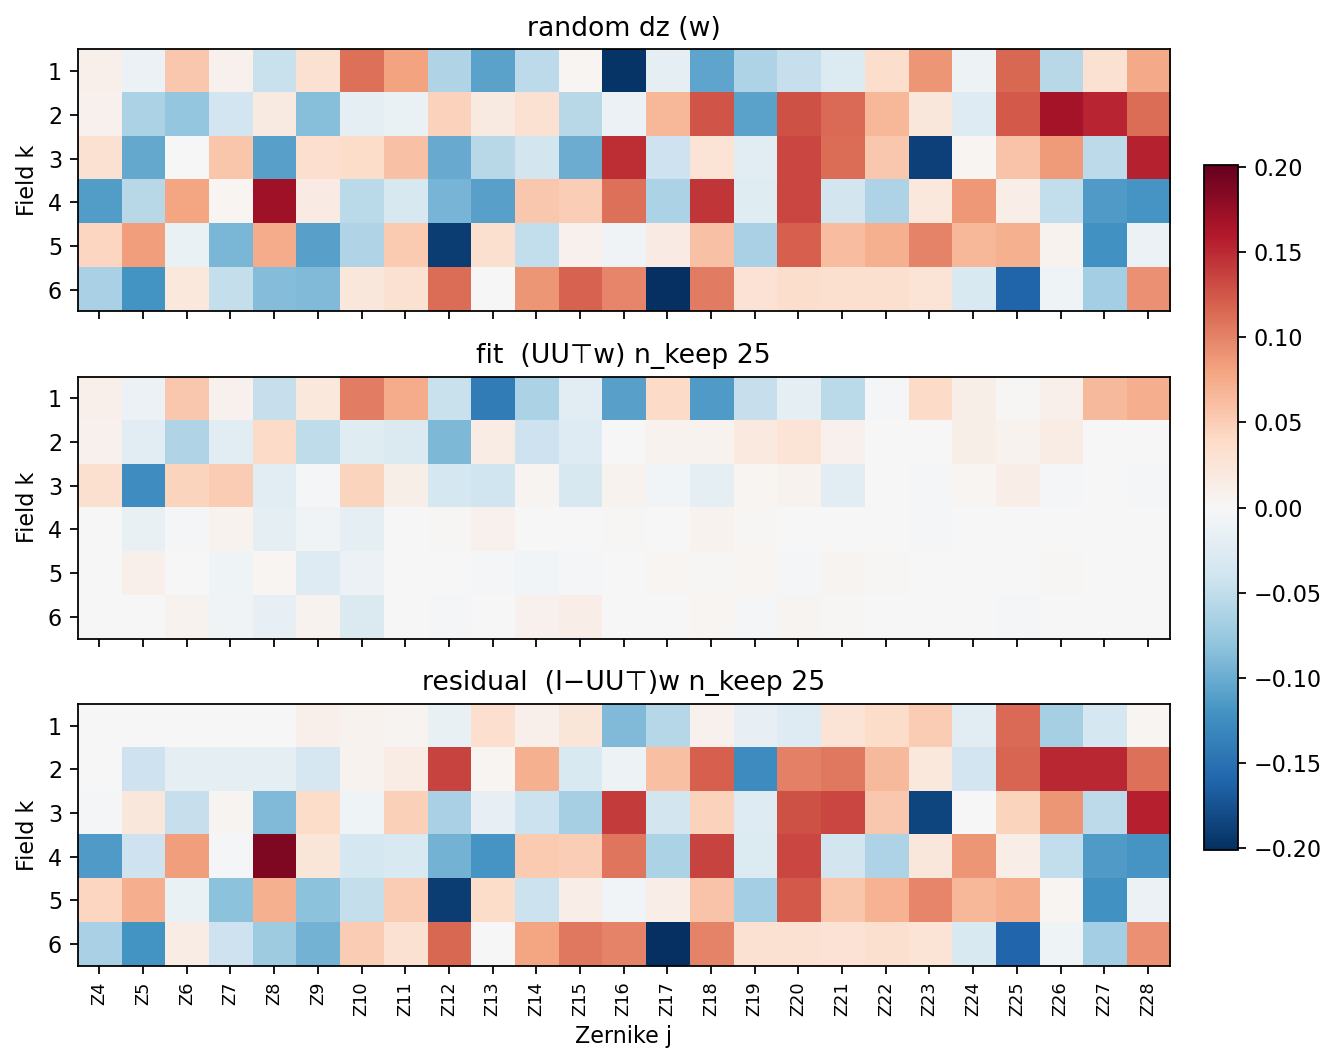

In [8]:
rng = np.random.default_rng(0)
w = rng.standard_normal(n_wf)
w /= np.linalg.norm(w)

coeffs   = U_eff.T @ w
fit      = U_eff @ coeffs
residual = w - fit

print(f'random DZ (||w||^2 = {np.dot(w, w):.4f}):')
print(f'  ||fit||^2      = {np.dot(fit, fit):.4f}')
print(f'  ||residual||^2 = {np.dot(residual, residual):.4f}')
print(f'  rank/n_wf      = {rank}/{n_wf} = {rank/n_wf:.4f}   (expectation over random w)')

# Visualize the residual per (k, j).
fig, axes = plt.subplots(3, 1, figsize=(11, 1.5*(0.55 * n_k + 1.2)), dpi=160, sharex=True)
vmax = max(np.abs(w).max(), np.abs(fit).max(), np.abs(residual).max())
for ax, vec, title in zip(
    axes,
    [w.reshape(n_k, n_j), fit.reshape(n_k, n_j), residual.reshape(n_k, n_j)],
    ['random dz (w)', rf'fit  (UU⊤w) n_keep {n_keep}', rf'residual  (I−UU⊤)w n_keep {n_keep}'],
):
    im = ax.imshow(vec, aspect='auto', cmap='RdBu_r',
                   norm=TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax))
    ax.set_xticks(np.arange(n_j))
    ax.set_xticklabels([f'Z{j}' for j in j_range], rotation=90, fontsize=8)
    ax.set_yticks(np.arange(n_k))
    ax.set_yticklabels([f'{k}' for k in k_range], fontsize=10)
    
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_ylabel('Field k')
axes[2].set_xlabel('Zernike j')
plt.tight_layout()
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
